In [11]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# force to show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns

In [15]:
# variables to find race and driver, also cut off time to take out yellow flags and pit stop laps
race_id = 5562
driver_id = 0
lap_time_cutoff = 25

In [16]:
# pull driver list from api
url = f'https://cf.nascar.com/cacher/2025/1/{race_id}/lap-times.json'
json = requests.get(url).json()
driver_list = pd.json_normalize(json['laps'])
driver_list = driver_list[['Number','FullName','Manufacturer','RunningPos']]

# find driver name
driver = pd.json_normalize(json['laps'][driver_id])
driver = driver['FullName'].iloc[0]

# find race name and location
url = 'https://cf.nascar.com/cacher/2025/race_list_basic.json'
json = requests.get(url).json()
race = pd.json_normalize(json['series_1'])
race = race[['race_id', 'track_name', 'race_name']].set_index('race_id')
race = race.loc[race_id]
location = race.values[0]
name = race.values[1]
race = name + ' @ ' + location

# find list of race ids
race_list = pd.json_normalize(json['series_1'])
race_list = race_list[['race_id', 'track_name', 'race_name']].set_index('race_id')

print(race_list)

print('\n' + driver + '\n')
print(race + '\n')
print(driver_list)

                                   track_name  \
race_id                                         
5543                      Bowman Gray Stadium   
5544           Daytona International Speedway   
5545           Daytona International Speedway   
5546           Daytona International Speedway   
5547                   Atlanta Motor Speedway   
5551                  Circuit of The Americas   
5549                          Phoenix Raceway   
5548                 Las Vegas Motor Speedway   
5583                 Homestead-Miami Speedway   
5553                    Martinsville Speedway   
5558                       Darlington Raceway   
5550                   Bristol Motor Speedway   
5555                  Talladega Superspeedway   
5554                     Texas Motor Speedway   
5557                          Kansas Speedway   
5561                North Wilkesboro Speedway   
5562                North Wilkesboro Speedway   
5563                 Charlotte Motor Speedway   
5568                

## Summary info

In [17]:
# driver laps
# take out yellow flag laps by lap_time_cutoff
# post fixed averages
# collect lap times and filter for yellows and pit stops
url = f'https://cf.nascar.com/cacher/2025/1/{race_id}/lap-times.json'
json = requests.get(url).json()

race_laps = pd.json_normalize(json['laps'][driver_id]['Laps'])
race_laps_filtered = race_laps[race_laps['LapTime'] < lap_time_cutoff]

# find driver name
driver = pd.json_normalize(json['laps'][driver_id])
driver = driver['FullName'].iloc[0][:-4]

# find race name and location
url = 'https://cf.nascar.com/cacher/2025/race_list_basic.json'
json = requests.get(url).json()
race = pd.json_normalize(json['series_1'])
race = race[['race_id', 'track_name', 'race_name']].set_index('race_id')
race = race.loc[race_id]
location = race.values[0]
name = race.values[1]
race = name + ' @ ' + location

print('\n\n' + driver + ', ' + race + '\n')

# Check if we have data after filtering
if race_laps_filtered.empty:
    print(f"No lap data found after filtering with cutoff {lap_time_cutoff}")
    print(f"Total laps before filtering: {len(race_laps)}")
    if not race_laps.empty:
        print(f"Lap time range: {race_laps['LapTime'].min()} - {race_laps['LapTime'].max()}")
        print("Try increasing the lap_time_cutoff value")
else:
    start_pos = race_laps['RunningPos'].head(1).to_numpy()
    start_pos = start_pos[0]
    end_pos = race_laps['RunningPos'].tail(1).to_numpy()
    end_pos = end_pos[0]

    print('Fastest Lap: ', race_laps_filtered['LapTime'].min())
    print('P50 Lap: ', round(np.quantile(race_laps_filtered['LapTime'], 0.5), 4))
    print('P95 Lap: ', round(np.quantile(race_laps_filtered['LapTime'], 0.95), 4), '\n')
    print('Averages:\n', round(race_laps_filtered[['LapTime','LapSpeed','RunningPos']].astype(float).mean(), 4), '\n\n')
    print(f'Started: P-{start_pos} \nEnded: P-{end_pos}')



Christopher Bell, NASCAR All-Star Race @ North Wilkesboro Speedway

Fastest Lap:  18.586
P50 Lap:  18.936
P95 Lap:  19.1999 

Averages:
 LapTime        18.9344
LapSpeed      118.8425
RunningPos      2.8698
dtype: float64 


Started: P-2 
Ended: P-1


## plotly chart: tire degredation with cleaned lap data

In [18]:
laptime = race_laps_filtered['LapTime']
lap = race_laps_filtered['Lap']
title = race + ': ' + driver



fig = px.scatter(x=lap, y=laptime, title=title + ' -- Laptimes by Lap', labels={'x':'Lap','y':'Laptime'}, trendline='rolling', trendline_options=dict(window=3), trendline_color_override='red')
fig.update_layout(paper_bgcolor='lightgray', plot_bgcolor='lightgray', yaxis=dict(autorange='reversed'))
fig.update_traces(marker=dict(color='blue'))
fig.add_hline(y=laptime.min(), line_width=0.5, line_color="black")
#print(fig)
fig.show()

In [19]:
fig = px.histogram(race_laps_filtered, x=laptime, title=title + ' -- Laptime Histogram', labels={'x':'Lap','y':'Laptime'})
fig.show()

In [23]:
running_position = []
running_position.append(['driver_name', 'start_pos', 'high_pos', 'low_pos', 'end_pos', 'pos_change'])

for i in np.arange(len(driver_list)):
    # pull lap times from api
    url = f'https://cf.nascar.com/cacher/2025/1/{race_id}/lap-times.json'
    json = requests.get(url).json()
    
    # collect dataframes for laps and driver name
    laps = pd.json_normalize(json['laps'][i]['Laps'])
    driver_name = pd.json_normalize(json['laps'][i])

    # put all the drivers together
    

    driver_name = driver_name['FullName'][0].lstrip('* ').rstrip('(i) #')
    start_pos = laps['RunningPos'].head(1)[0].item()
    high_pos = laps['RunningPos'].min().item()
    low_pos = laps['RunningPos'].max().item()
    end_pos = laps['RunningPos'].tail(1).to_numpy()[0].item()
    pos_change = start_pos - end_pos
    

    new_driver = [driver_name, start_pos, high_pos, low_pos, end_pos, pos_change]

    #running_position_start = np.vstack((running_position, new_driver))
    #running_position_updated = np.vstack((running_position_start, new_driver))

    running_position.append(new_driver)

df = pd.DataFrame(running_position[1:], columns=running_position[0])

print(df)

                driver_name  start_pos  high_pos  low_pos  end_pos  pos_change
0       Christopher Bell (T          2         1        9        1           1
1            Joey Logano (F          4         1        8        2           2
2          Ross Chastain (C          3         2       21        3           0
3            Alex Bowman (C          9         1       12        4           5
4          Chase Elliott (C          6         2       10        5           1
5          William Byron (C          5         1       11        6          -1
6          Tyler Reddick (T         13         6       16        7           6
7             Kyle Busch (C          8         1       13        8           0
8          Chase Briscoe (T         14         2       18        9           5
9         Chris Buescher (F         10         7       19       10           0
10           Carson Hocevar         21         3       22       11          10
11          Denny Hamlin (T         20        12    

     driver_name  start_pos  high_pos  low_pos  end_pos  pos_change
0    Kyle Larson          3         1       15        1           2
1   Denny Hamlin          4         2       18        2           2
2       Ty Gibbs          6         3       21        3           3
3  Chase Briscoe         14         3       18        4          10
4    Ryan Blaney          5         1       14        5           0


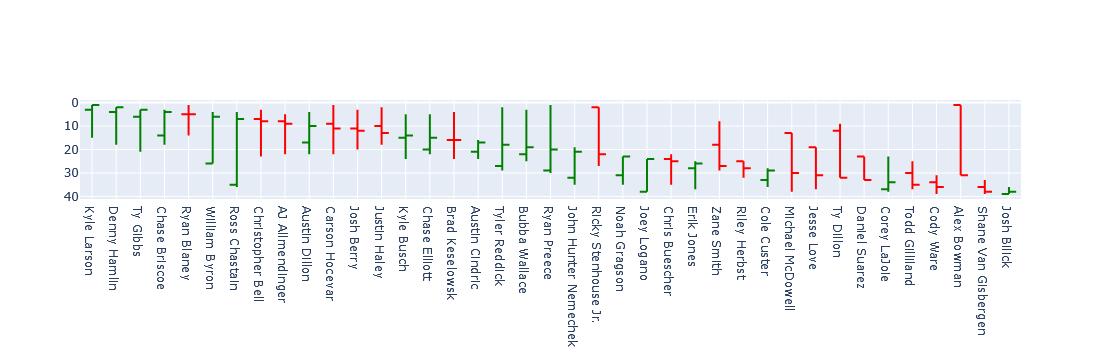

In [8]:
print(df.head())

fig = go.Figure(data=go.Ohlc(x=df['driver_name'], open=df['start_pos'], high=df['low_pos'], low=df['high_pos'], close=df['end_pos'], increasing={'line': {'color': 'red'}}, decreasing={'line': {'color': 'green'}}))
fig.update(layout_xaxis_rangeslider_visible=False)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [24]:
# bar chart start vs finish positions

clrs = ['red' if (x < 0) else 'green' for x in df['pos_change'].astype(int) ]



fig = px.bar(x=df['driver_name'], y=df['pos_change'], title="Position Change: Start vs Finish -- Food City 500", labels={"x": "Driver Starting Position", "y": "Position Change"})
fig.update_layout(paper_bgcolor='lightgray', plot_bgcolor='lightgray', yaxis={'tickmode':'linear', 'tick0':-30, 'dtick':5})
fig.update_traces(marker_color=clrs)
fig.update_xaxes(tickangle=-90)
fig.add_hline(y=0, line_width=0.5, line_color="black")
fig.show()

## Graph: Lap Times on top of Running Position

In [25]:
print(race_laps_filtered.head(5))
laps = race_laps_filtered['Lap']
lap_time = race_laps_filtered['LapTime']
run_pos = race_laps_filtered['RunningPos']


fig = go.Figure()
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_bar(x=laps, y=run_pos)
fig.add_trace(go.Scatter(x=laps, y=lap_time, mode='lines'), secondary_y=True)
fig.update_yaxes(autorange='reversed')
fig.show()

   Lap  LapTime LapSpeed  RunningPos
1    1   19.459  115.628           2
2    2   19.035  118.203           3
3    3   19.327  116.417           4
4    4   18.936  118.821           5
5    5   18.816  119.579           5
